Na etapa de EDA, o grupo deve realizar uma análise exploratória abrangente para entender a estrutura, qualidade, distribuições, relações entre variáveis (numéricas e categóricas) e desafios, como missing values e vieses, preparando para encoding e modelagem nas fases subsequentes.
Descrição do Dataset: O dataset Adult consiste em 48.842 instâncias, cada uma representando um indivíduo com 14 features mistas e o target 'income'. Valores ausentes são representados por '?'. Use o conjunto completo para EDA, mas amostras estratificadas (por income) para visualizações eficientes se necessário.

Tarefas básicas de EDA:

1. Carregamento e inspeção inicial dos dados:

    - Explicar cada feature do dataset;
    - Verificar o número de instâncias e features.
    - Identificar tipos de dados (numéricos, categóricos).
    - Detectar valores ausentes ('?') e inconsistências.
    - Analisar a distribuição do target 'income'.

In [1]:
import pandas as pd
import numpy as np

# Ler arquivo de documentação para entender o dataset
with open('adult/adult.names', 'r') as f:
    doc_lines = f.readlines()

print("\nNomes das features encontrados na documentação:\n")
feature_lines = []
for line in doc_lines[96:200]:  # Linhas onde estão os nomes das features
    if ':' in line and not line.startswith('|'):
        feature_name = line.split(':')[0].strip()
        feature_lines.append(line.strip())
        print(f"  {line.strip()}")

# Definir nomes das colunas baseado na documentação
column_names = [line.split(':')[0].strip() for line in feature_lines]
column_names.append('income')

print("\nColunas finais usadas no DataFrame:")
print(column_names)

# Carregar dataset
df = pd.read_csv('adult/adult.data', names=column_names, skipinitialspace=True)


Nomes das features encontrados na documentação:

  age: continuous.
  workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
  fnlwgt: continuous.
  education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
  education-num: continuous.
  marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
  occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
  relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
  race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
  sex: Female, Male.
  capital-gain: continuous.
  capital-loss: continuous.
  hours-per-w

## 1. Explicação de cada Feature do Dataset

In [2]:
print("1. EXPLICAÇÃO DE CADA FEATURE")

# Analisar tipos de dados diretamente do DataFrame
for col, dtype in df.dtypes.items():
    print(f"  {col:20s}: {dtype}")

# Descrições baseadas na documentação + análise dos dados
feature_descriptions = {
    'age': 'Idade do indivíduo',
    'workclass': 'Tipo de empregador',
    'fnlwgt': 'Peso amostral - representa quantas pessoas o registro representa na população',
    'education': 'Nível educacional',
    'education-num': 'Nível educacional convertido em número',
    'marital-status': 'Estado civil',
    'occupation': 'Tipo de ocupação/profissão',
    'relationship': 'Papel na família',
    'race': 'Raça/etnia',
    'sex': 'Sexo',
    'capital-gain': 'Ganhos de capital financeiro',
    'capital-loss': 'Perdas de capital financeiro',
    'hours-per-week': 'Horas trabalhadas por semana',
    'native-country': 'País de origem',
    'income': 'TARGET - Se ganha mais que $50K/ano'
}

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    desc = feature_descriptions.get(col, 'Sem descrição')
    
    # Determinar tipo baseado no dtype do pandas
    if dtype in ['int64', 'float64']:
        tipo = 'NUMÉRICA'
    else:
        tipo = 'CATEGÓRICA'
    
    print(f"\n{i:2d}. {col:20s}")
    print(f"    Descrição: {desc}")
    print(f"    Tipo: {tipo} (dtype: {dtype})")

1. EXPLICAÇÃO DE CADA FEATURE
  age                 : int64
  workclass           : object
  fnlwgt              : int64
  education           : object
  education-num       : int64
  marital-status      : object
  occupation          : object
  relationship        : object
  race                : object
  sex                 : object
  capital-gain        : int64
  capital-loss        : int64
  hours-per-week      : int64
  native-country      : object
  income              : object

 1. age                 
    Descrição: Idade do indivíduo
    Tipo: NUMÉRICA (dtype: int64)

 2. workclass           
    Descrição: Tipo de empregador
    Tipo: CATEGÓRICA (dtype: object)

 3. fnlwgt              
    Descrição: Peso amostral - representa quantas pessoas o registro representa na população
    Tipo: NUMÉRICA (dtype: int64)

 4. education           
    Descrição: Nível educacional
    Tipo: CATEGÓRICA (dtype: object)

 5. education-num       
    Descrição: Nível educacional convertido e

## 2. Verificar Número de Instâncias e Features

In [3]:
print("2. NÚMERO DE INSTÂNCIAS E FEATURES")

print(f"\nNúmero de instâncias (linhas): {df.shape[0]:,}")
print(f"Número de features (colunas): {df.shape[1]}")
print(f"  - Features preditoras: {df.shape[1] - 1}")
print(f"  - Target (income): 1")

print("\nPrimeiras 3 linhas do dataset:")
print(df.head(3))

2. NÚMERO DE INSTÂNCIAS E FEATURES

Número de instâncias (linhas): 32,561
Número de features (colunas): 15
  - Features preditoras: 14
  - Target (income): 1

Primeiras 3 linhas do dataset:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital-status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  

## 3. Identificar Tipos de Dados (Numéricos e Categóricos)

In [4]:
print("3. IDENTIFICAÇÃO DE TIPOS DE DADOS")

# Separar por tipo
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Remover target das listas
if 'income' in categorical:
    categorical.remove('income')

print(f"\nFeatures NUMÉRICAS ({len(numerical)}):")
for feat in numerical:
    print(f"  - {feat}")

print(f"\nFeatures CATEGÓRICAS ({len(categorical)}):")
for feat in categorical:
    print(f"  - {feat}")

3. IDENTIFICAÇÃO DE TIPOS DE DADOS

Features NUMÉRICAS (6):
  - age
  - fnlwgt
  - education-num
  - capital-gain
  - capital-loss
  - hours-per-week

Features CATEGÓRICAS (8):
  - workclass
  - education
  - marital-status
  - occupation
  - relationship
  - race
  - sex
  - native-country


## 4. Detectar Valores Ausentes ('?') e Inconsistências

In [5]:
print("4. DETECÇÃO DE VALORES AUSENTES E INCONSISTÊNCIAS")

# Detectar '?' nas features categóricas
for col in categorical + ['income']:
    count = (df[col] == '?').sum()
    if count > 0:
        pct = (count / len(df)) * 100
        print(f"  - {col:20s}: {count:5,} ({pct:.2f}%)")

# Total de linhas com missing
linhas_com_missing = df[df.isin(['?']).any(axis=1)].shape[0]
print(f"\nTotal de instâncias com valores ausentes: {linhas_com_missing:,} ({linhas_com_missing/len(df)*100:.2f}%)")

# Verificar duplicatas
duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicatas:,}")

4. DETECÇÃO DE VALORES AUSENTES E INCONSISTÊNCIAS
  - workclass           : 1,836 (5.64%)
  - occupation          : 1,843 (5.66%)
  - native-country      :   583 (1.79%)

Total de instâncias com valores ausentes: 2,399 (7.37%)
Linhas duplicadas: 24


## 5. Analisar a Distribuição do Target 'income'

In [6]:
print("5. DISTRIBUIÇÃO DO TARGET 'INCOME'")

# Contar classes
distribuicao = df['income'].value_counts()
percentual = df['income'].value_counts(normalize=True) * 100

# Distribuição das classes
for classe, qtd in distribuicao.items():
    pct = percentual[classe]
    print(f"  {classe:8s}: {qtd:6,} ({pct:5.2f}%)")

print(f"  {'TOTAL':8s}: {len(df):6,} (100.00%)")

# Análise de balanceamento
razao = distribuicao.max() / distribuicao.min()
print(f"\nRazão entre classe majoritária/minoritária: {razao:.2f}:1")

if razao > 2:
    print(f"\nCONCLUSÃO: Dataset DESBALANCEADO")
else:
    print(f"\nCONCLUSÃO: Dataset balanceado")

5. DISTRIBUIÇÃO DO TARGET 'INCOME'
  <=50K   : 24,720 (75.92%)
  >50K    :  7,841 (24.08%)
  TOTAL   : 32,561 (100.00%)

Razão entre classe majoritária/minoritária: 3.15:1

CONCLUSÃO: Dataset DESBALANCEADO


# 2. Análise Univariada

Nesta seção, analisamos cada variável individualmente:
- **Variáveis numéricas**: estatísticas descritivas (média, mediana, desvio padrão) + histogramas e boxplots
- **Variáveis categóricas**: frequências absolutas e relativas + gráficos de barras
- **Detecção de outliers**: via boxplots e z-scores

## 2.1 Variáveis Numéricas — Estatísticas Descritivas

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Reconstruir listas de features (caso cells sejam executadas isoladamente)
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')

# Estatísticas descritivas para variáveis numéricas
print("2.1 ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS\n")

stats = df[numerical].describe().T
stats['median'] = df[numerical].median()
stats['skew'] = df[numerical].skew()
stats['kurtosis'] = df[numerical].kurtosis()

# Reorganizar colunas para melhor leitura
stats = stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']]
print(stats.to_string())

print("\n\nINSIGHTS:")
print("  - capital-gain e capital-loss possuem alta assimetria (skew) e curtose,")
print("    indicando que a maioria dos valores é 0 com poucos valores extremos.")
print("  - fnlwgt tem grande amplitude (12K a 1.5M), refletindo pesos amostrais variados.")
print("  - age e hours-per-week apresentam distribuições mais simétricas.")

2.1 ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS

                  count           mean    median            std      min       25%       50%       75%        max       skew    kurtosis
age             32561.0      38.581647      37.0      13.640433     17.0      28.0      37.0      48.0       90.0   0.558743   -0.166127
fnlwgt          32561.0  189778.366512  178356.0  105549.977697  12285.0  117827.0  178356.0  237051.0  1484705.0   1.446980    6.218811
education-num   32561.0      10.080679      10.0       2.572720      1.0       9.0      10.0      12.0       16.0  -0.311676    0.623444
capital-gain    32561.0    1077.648844       0.0    7385.292085      0.0       0.0       0.0       0.0    99999.0  11.953848  154.799438
capital-loss    32561.0      87.303830       0.0     402.960219      0.0       0.0       0.0       0.0     4356.0   4.594629   20.376802
hours-per-week  32561.0      40.437456      40.0      12.347429      1.0      40.0      40.0      45.0       99.0   0.227643  

## 2.2 Variáveis Numéricas — Histogramas

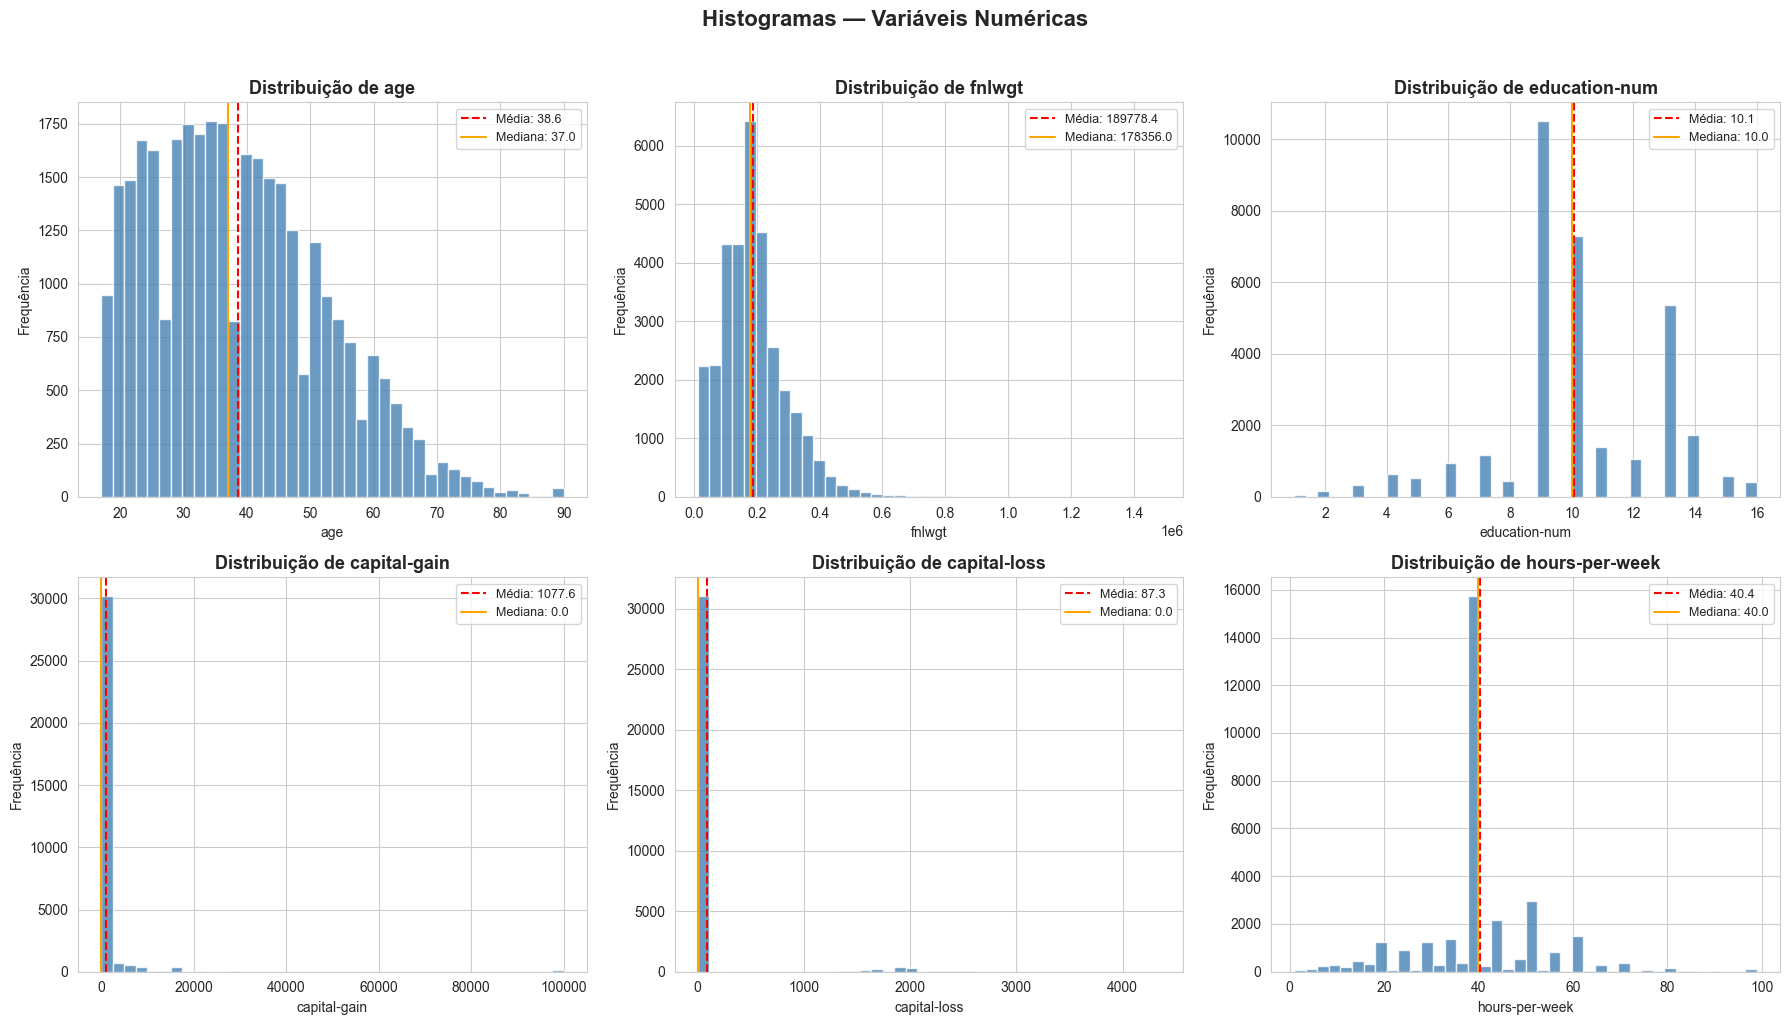

OBSERVAÇÕES:
  - age: distribuição levemente assimétrica à direita, concentrada entre 20-50 anos.
  - fnlwgt: assimetria à direita com cauda longa.
  - education-num: distribuição multimodal, com picos em 9 (HS-grad) e 13 (Bachelors).
  - capital-gain e capital-loss: extremamente concentrados em 0 (a grande maioria não tem ganhos/perdas de capital).
  - hours-per-week: pico forte em 40h (jornada padrão), com cauda à direita.


In [8]:
# Histogramas para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Média: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.suptitle('Histogramas — Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - age: distribuição levemente assimétrica à direita, concentrada entre 20-50 anos.")
print("  - fnlwgt: assimetria à direita com cauda longa.")
print("  - education-num: distribuição multimodal, com picos em 9 (HS-grad) e 13 (Bachelors).")
print("  - capital-gain e capital-loss: extremamente concentrados em 0 (a grande maioria não tem ganhos/perdas de capital).")
print("  - hours-per-week: pico forte em 40h (jornada padrão), com cauda à direita.")

## 2.3 Variáveis Numéricas — Boxplots

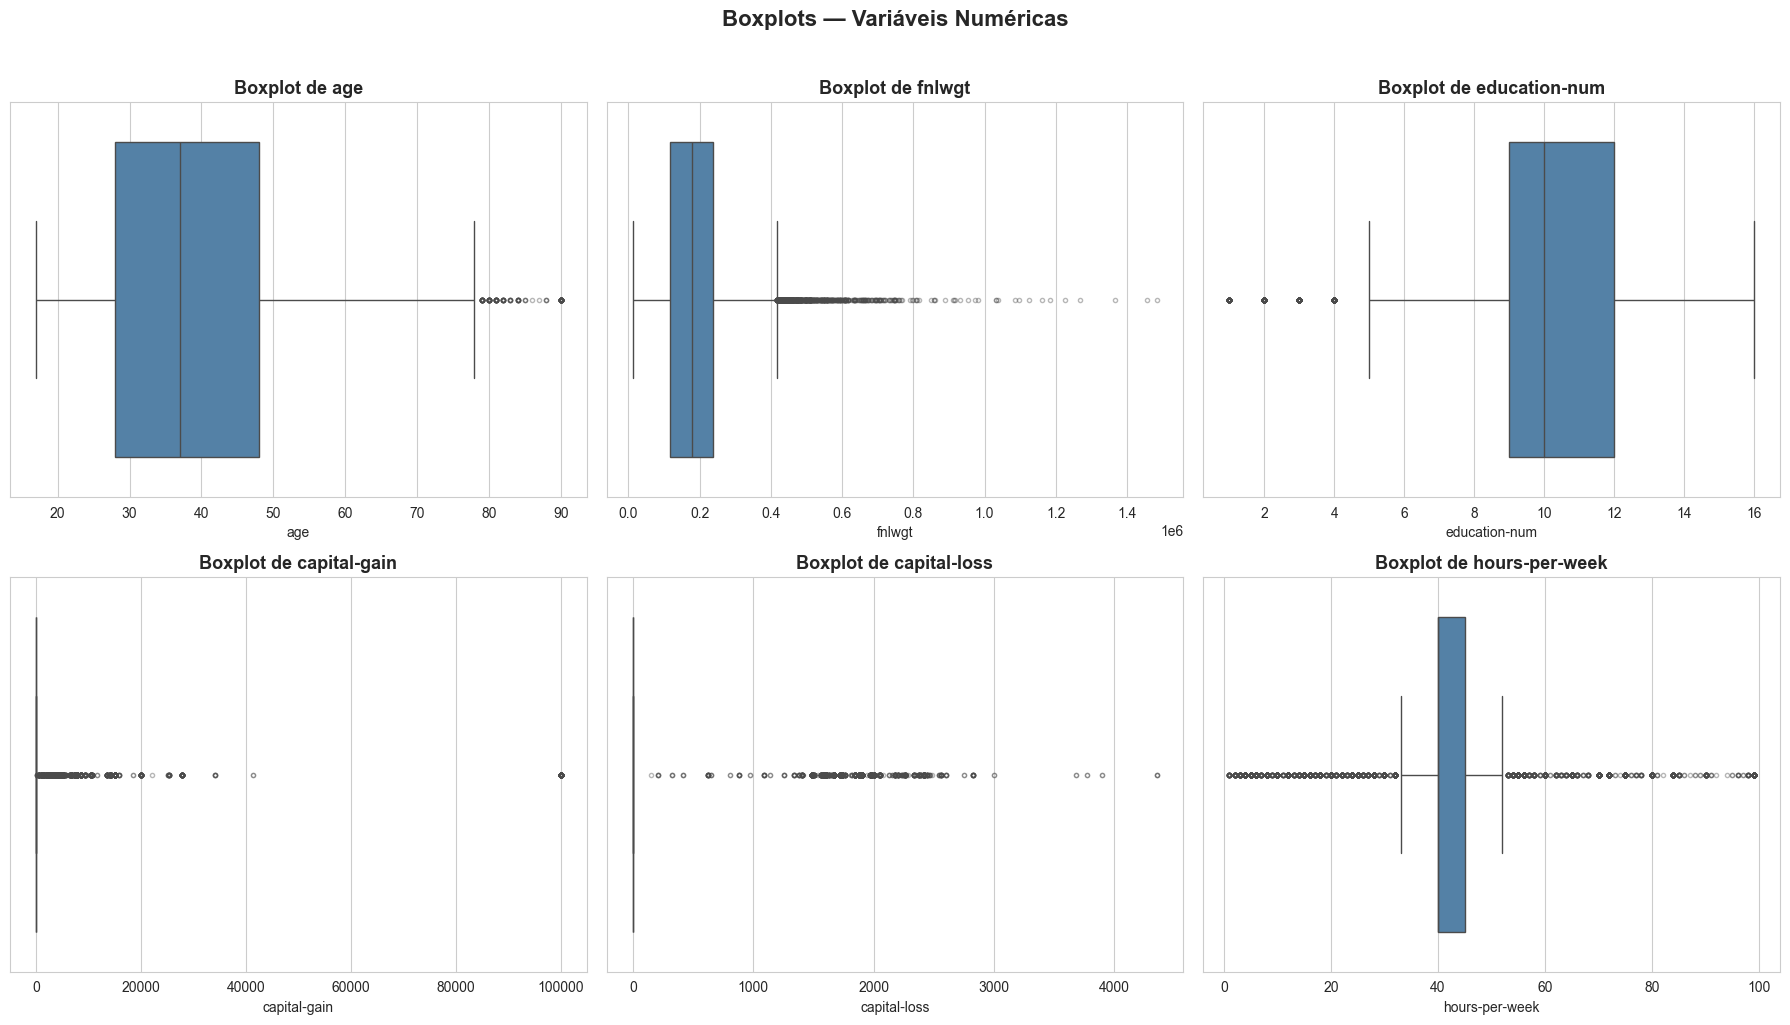

OBSERVAÇÕES:
  - age: poucos outliers acima de ~73 anos.
  - fnlwgt: muitos outliers à direita (pesos amostrais altos).
  - capital-gain: outliers extremos (valores > 0 já são atípicos, pois 75% dos dados são 0).
  - capital-loss: padrão similar ao capital-gain.
  - hours-per-week: outliers em ambos os extremos (quem trabalha muito pouco ou muito).


In [9]:
# Boxplots para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color='steelblue', flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(f'Boxplot de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Boxplots — Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - age: poucos outliers acima de ~73 anos.")
print("  - fnlwgt: muitos outliers à direita (pesos amostrais altos).")
print("  - capital-gain: outliers extremos (valores > 0 já são atípicos, pois 75% dos dados são 0).")
print("  - capital-loss: padrão similar ao capital-gain.")
print("  - hours-per-week: outliers em ambos os extremos (quem trabalha muito pouco ou muito).")

## 2.4 Variáveis Categóricas — Frequências e Gráficos de Barras

In [10]:
# Tabela de frequências para cada variável categórica
print("2.4 FREQUÊNCIAS — VARIÁVEIS CATEGÓRICAS\n")

for col in categorical:
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    
    print(f"{'='*60}")
    print(f"  {col} ({df[col].nunique()} categorias)")
    print(f"{'='*60}")
    for cat in freq.index:
        print(f"    {cat:30s}: {freq[cat]:6,} ({pct[cat]:5.2f}%)")
    print()

2.4 FREQUÊNCIAS — VARIÁVEIS CATEGÓRICAS

  workclass (9 categorias)
    Private                       : 22,696 (69.70%)
    Self-emp-not-inc              :  2,541 ( 7.80%)
    Local-gov                     :  2,093 ( 6.43%)
    ?                             :  1,836 ( 5.64%)
    State-gov                     :  1,298 ( 3.99%)
    Self-emp-inc                  :  1,116 ( 3.43%)
    Federal-gov                   :    960 ( 2.95%)
    Without-pay                   :     14 ( 0.04%)
    Never-worked                  :      7 ( 0.02%)

  education (16 categorias)
    HS-grad                       : 10,501 (32.25%)
    Some-college                  :  7,291 (22.39%)
    Bachelors                     :  5,355 (16.45%)
    Masters                       :  1,723 ( 5.29%)
    Assoc-voc                     :  1,382 ( 4.24%)
    11th                          :  1,175 ( 3.61%)
    Assoc-acdm                    :  1,067 ( 3.28%)
    10th                          :    933 ( 2.87%)
    7th-8th        

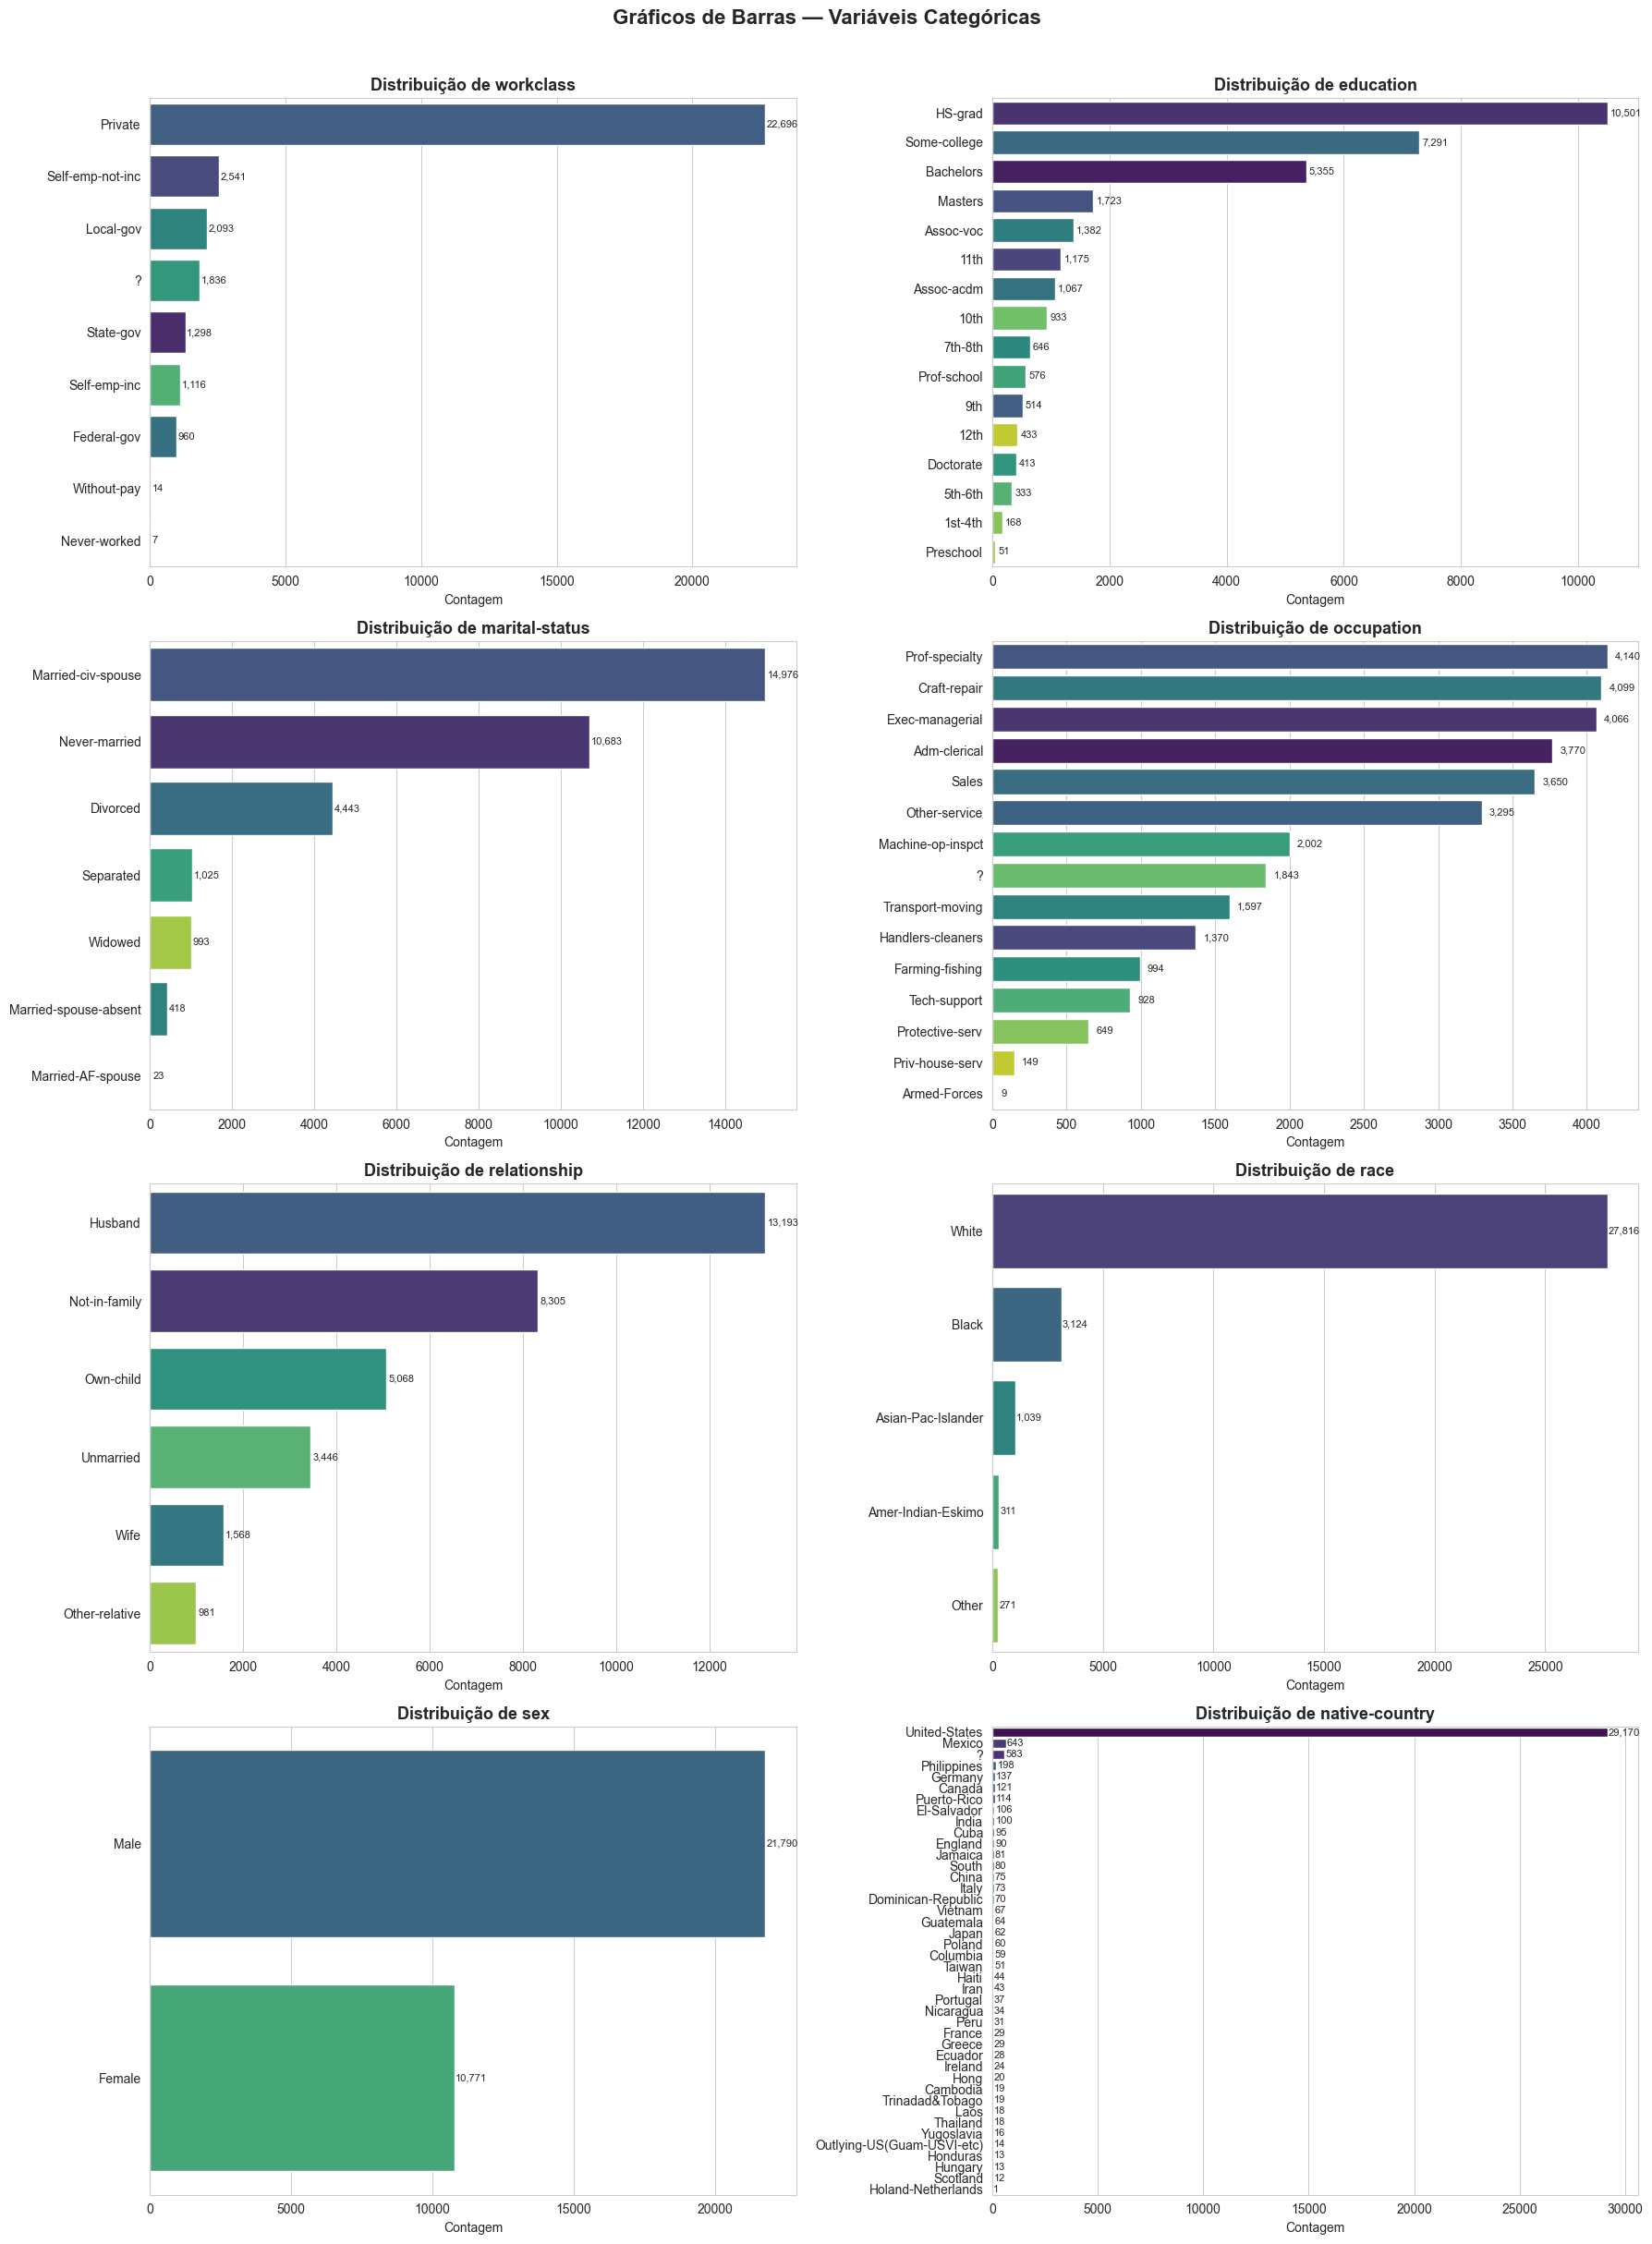

OBSERVAÇÕES:
  - workclass: dominado por 'Private' (~75%). Categorias 'Without-pay' e 'Never-worked' são raríssimas.
  - education: 'HS-grad' é a mais comum, seguida por 'Some-college' e 'Bachelors'.
  - marital-status: 'Married-civ-spouse' e 'Never-married' são as mais frequentes.
  - occupation: relativamente equilibrada, com 'Prof-specialty' e 'Craft-repair' liderando.
  - relationship: 'Husband' é o mais comum, refletindo predominância masculina no dataset.
  - race: fortemente dominado por 'White' (~85%).
  - sex: desbalanceado — ~67% Male vs ~33% Female.
  - native-country: ~90% dos registros são de 'United-States'.


In [11]:
# Gráficos de barras para variáveis categóricas
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(categorical):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette='viridis', hue=df[col], legend=False)
    ax.set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Contagem')
    ax.set_ylabel('')
    
    # Adicionar contagem nas barras
    for bar in ax.patches:
        width = bar.get_width()
        if width > 0:
            ax.text(width + 50, bar.get_y() + bar.get_height()/2,
                    f'{int(width):,}', va='center', fontsize=8)

plt.suptitle('Gráficos de Barras — Variáveis Categóricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - workclass: dominado por 'Private' (~75%). Categorias 'Without-pay' e 'Never-worked' são raríssimas.")
print("  - education: 'HS-grad' é a mais comum, seguida por 'Some-college' e 'Bachelors'.")
print("  - marital-status: 'Married-civ-spouse' e 'Never-married' são as mais frequentes.")
print("  - occupation: relativamente equilibrada, com 'Prof-specialty' e 'Craft-repair' liderando.")
print("  - relationship: 'Husband' é o mais comum, refletindo predominância masculina no dataset.")
print("  - race: fortemente dominado por 'White' (~85%).")
print("  - sex: desbalanceado — ~67% Male vs ~33% Female.")
print("  - native-country: ~90% dos registros são de 'United-States'.")

## 2.5 Detecção de Outliers — Boxplots e Z-Scores

Utilizamos duas abordagens complementares para detectar outliers nas variáveis numéricas:
1. **Método IQR (Interquartile Range)**: outliers são valores abaixo de Q1 - 1.5×IQR ou acima de Q3 + 1.5×IQR
2. **Z-Score**: outliers são valores com |z| > 3 (mais de 3 desvios padrão da média)

In [12]:
from scipy import stats

print("2.5 DETECÇÃO DE OUTLIERS — MÉTODO IQR E Z-SCORE\n")
print(f"{'Feature':20s} | {'Outliers IQR':>14s} | {'% IQR':>8s} | {'Outliers Z>3':>14s} | {'% Z>3':>8s}")
print("-" * 78)

outlier_summary = {}

for col in numerical:
    # Método IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_iqr = (outliers_iqr / len(df)) * 100
    
    # Método Z-Score
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_z = (z_scores > 3).sum()
    pct_z = (outliers_z / len(df)) * 100
    
    outlier_summary[col] = {
        'iqr_count': outliers_iqr, 'iqr_pct': pct_iqr,
        'z_count': outliers_z, 'z_pct': pct_z,
        'iqr_lower': lower, 'iqr_upper': upper
    }
    
    print(f"{col:20s} | {outliers_iqr:14,} | {pct_iqr:7.2f}% | {outliers_z:14,} | {pct_z:7.2f}%")

print("\n\nINSIGHTS:")
print("  - capital-gain: ~92% dos valores são 0; qualquer ganho > 0 tende a ser 'outlier' pelo IQR.")
print("    O z-score é mais conservador e captura apenas os ganhos realmente extremos.")
print("  - capital-loss: padrão similar ao capital-gain.")
print("  - fnlwgt: muitos outliers pelo IQR (~8%), refletindo a cauda longa da distribuição.")
print("  - age e hours-per-week: poucos outliers, distribuições relativamente bem comportadas.")
print("  - education-num: praticamente sem outliers, por ser uma escala ordinal limitada (1-16).")

2.5 DETECÇÃO DE OUTLIERS — MÉTODO IQR E Z-SCORE

Feature              |   Outliers IQR |    % IQR |   Outliers Z>3 |    % Z>3
------------------------------------------------------------------------------
age                  |            143 |    0.44% |            121 |    0.37%
fnlwgt               |            992 |    3.05% |            347 |    1.07%
education-num        |          1,198 |    3.68% |            219 |    0.67%
capital-gain         |          2,712 |    8.33% |            215 |    0.66%
capital-loss         |          1,519 |    4.67% |          1,470 |    4.51%
hours-per-week       |          9,008 |   27.66% |            440 |    1.35%


INSIGHTS:
  - capital-gain: ~92% dos valores são 0; qualquer ganho > 0 tende a ser 'outlier' pelo IQR.
    O z-score é mais conservador e captura apenas os ganhos realmente extremos.
  - capital-loss: padrão similar ao capital-gain.
  - fnlwgt: muitos outliers pelo IQR (~8%), refletindo a cauda longa da distribuição.
  - age e ho

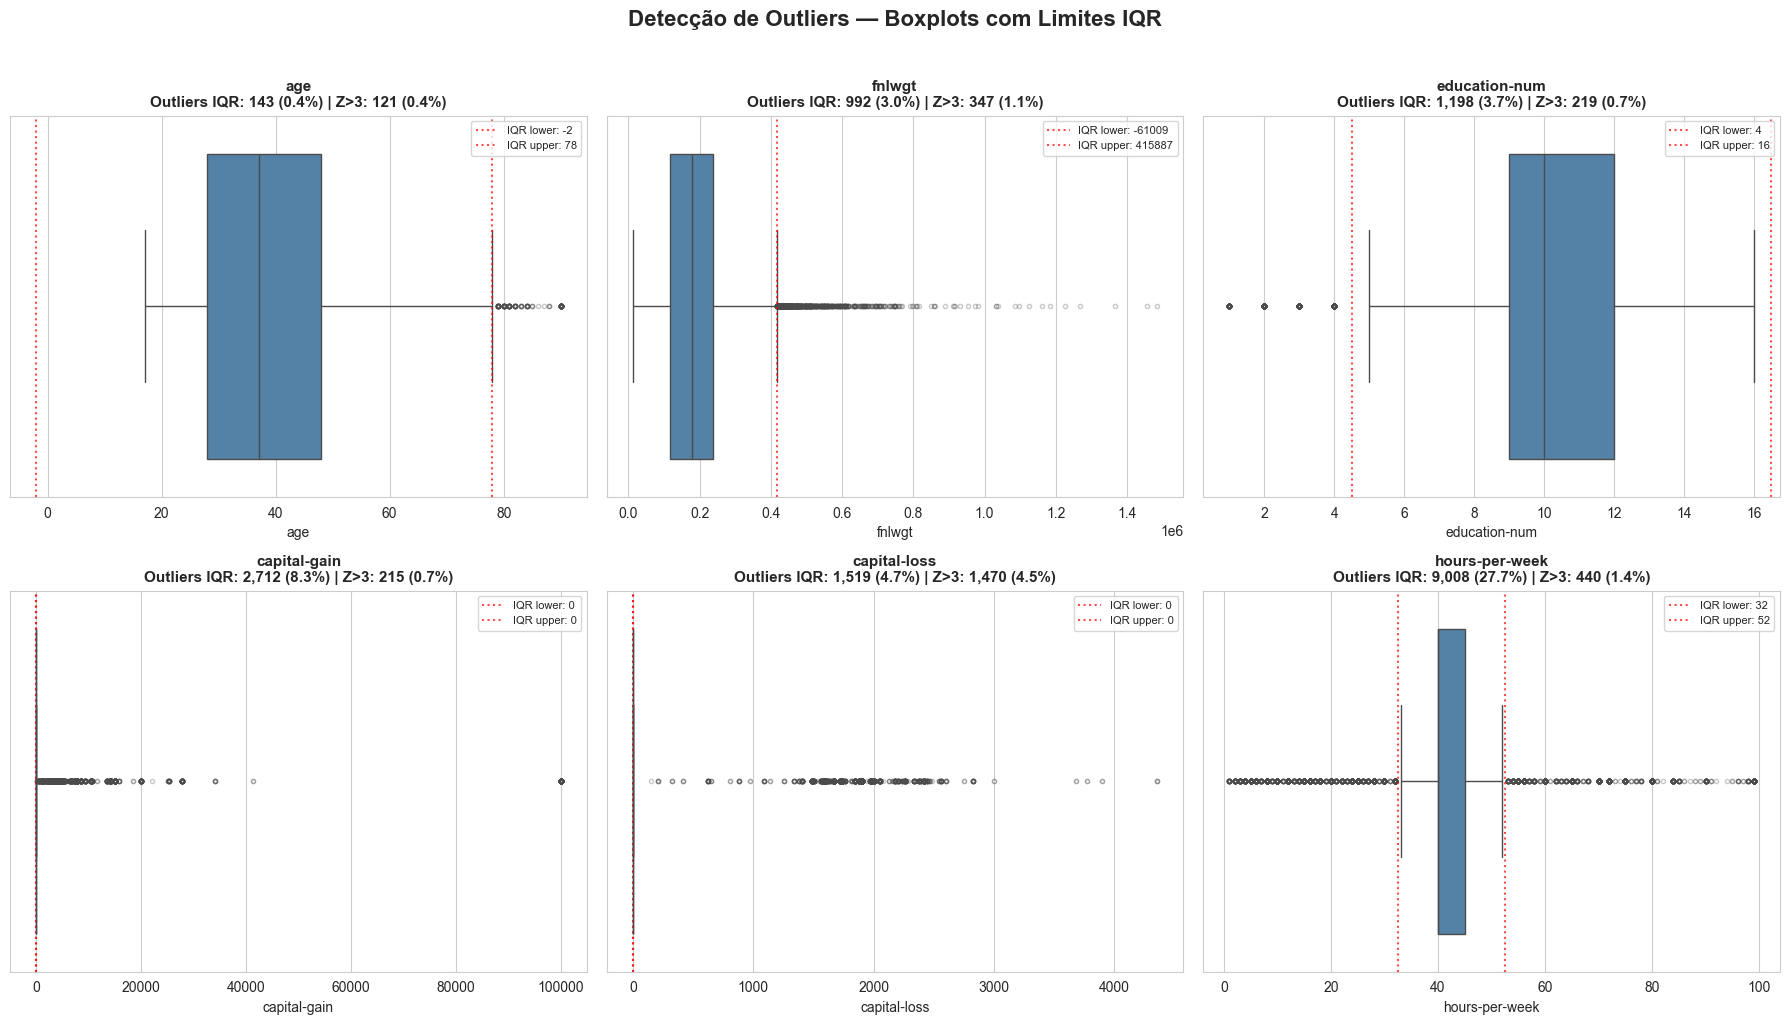

In [13]:
# Visualização: Boxplots com limites IQR destacados
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color='steelblue',
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='red'))
    
    info = outlier_summary[col]
    ax.axvline(info['iqr_lower'], color='red', linestyle=':', alpha=0.7, label=f'IQR lower: {info["iqr_lower"]:.0f}')
    ax.axvline(info['iqr_upper'], color='red', linestyle=':', alpha=0.7, label=f'IQR upper: {info["iqr_upper"]:.0f}')
    
    ax.set_title(f'{col}\nOutliers IQR: {info["iqr_count"]:,} ({info["iqr_pct"]:.1f}%) | Z>3: {info["z_count"]:,} ({info["z_pct"]:.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Detecção de Outliers — Boxplots com Limites IQR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

3. Análise bivariada e multivariada:

    - Analisar correlações entre variáveis numéricas usando matrizes de correlação e scatter plots (use heatmaps para visualização).
    - Analisar relações entre variáveis categóricas e o target 'income' usando gráficos de barras ou tabelas de contingência.
    - Analisar relações entre variáveis numéricas e categóricas usando boxplots ou violin plots.

## 3.1 Analisar correlações entre variáveis numéricas

- Utilizar matriz de correlação e heatmap para visualizar as relações.
- Complementar com scatter plots dos pares numéricos mais correlacionados.

                  age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week
age             1.000  -0.077          0.037         0.078         0.058           0.069
fnlwgt         -0.077   1.000         -0.043         0.000        -0.010          -0.019
education-num   0.037  -0.043          1.000         0.123         0.080           0.148
capital-gain    0.078   0.000          0.123         1.000        -0.032           0.078
capital-loss    0.058  -0.010          0.080        -0.032         1.000           0.054
hours-per-week  0.069  -0.019          0.148         0.078         0.054           1.000


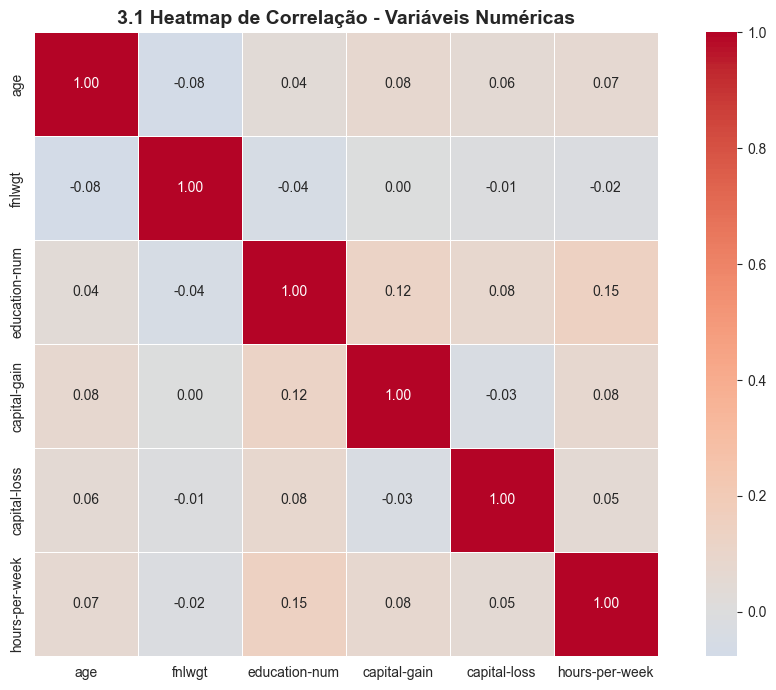

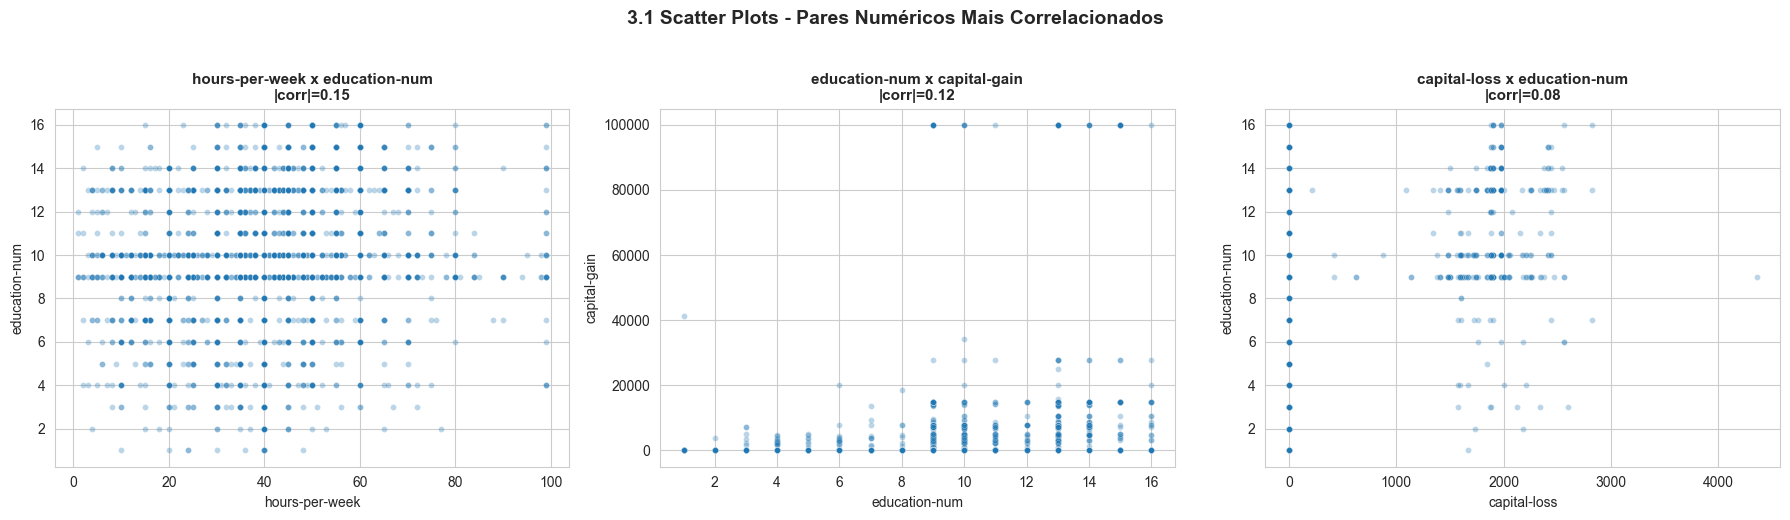

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

if 'df' not in globals():
    raise ValueError("DataFrame 'df' não encontrado. Execute as células da seção 1 antes desta.")


numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')


# Matriz de correlação
corr = df[numerical].corr(numeric_only=True)
print(corr.round(3).to_string())

# Heatmap de correlação
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('3.1 Heatmap de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plots para pares com correlação mais relevante
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .abs()
        .stack()
        .sort_values(ascending=False)
)

used = set()
top_pairs = []
for (a, b), value in corr_pairs.items():
    key = tuple(sorted((a, b)))
    if key not in used:
        used.add(key)
        top_pairs.append((a, b, value))
    if len(top_pairs) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (x_col, y_col, val) in enumerate(top_pairs):
    ax = axes[i]
    plot_df = df[[x_col, y_col]].sample(min(8000, len(df)), random_state=42)
    sns.scatterplot(data=plot_df, x=x_col, y=y_col, alpha=0.3, s=18, ax=ax)
    ax.set_title(f'{x_col} x {y_col}\n|corr|={val:.2f}', fontsize=11, fontweight='bold')

plt.suptitle('3.1 Scatter Plots - Pares Numéricos Mais Correlacionados', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 3.2 Analisar relações entre variáveis categóricas e o target `income`

- Usar tabelas de contingência e/ou proporções por categoria.
- Visualizar com gráficos de barras empilhadas para comparar `<=50K` vs `>50K`.

workclass - Taxa de >50K (top 8 categorias)
workclass
Self-emp-inc        55.73
Federal-gov         38.65
Local-gov           29.48
Self-emp-not-inc    28.49
State-gov           27.20
Private             21.87
?                   10.40
Never-worked         0.00

education - Taxa de >50K (top 8 categorias)
education
Doctorate       74.09
Prof-school     73.44
Masters         55.66
Bachelors       41.48
Assoc-voc       26.12
Assoc-acdm      24.84
Some-college    19.02
HS-grad         15.95

marital-status - Taxa de >50K (top 8 categorias)
marital-status
Married-civ-spouse       44.68
Married-AF-spouse        43.48
Divorced                 10.42
Widowed                   8.56
Married-spouse-absent     8.13
Separated                 6.44
Never-married             4.60

occupation - Taxa de >50K (top 8 categorias)
occupation
Exec-managerial     48.40
Prof-specialty      44.90
Protective-serv     32.51
Tech-support        30.50
Sales               26.93
Craft-repair        22.66
Transport-mo

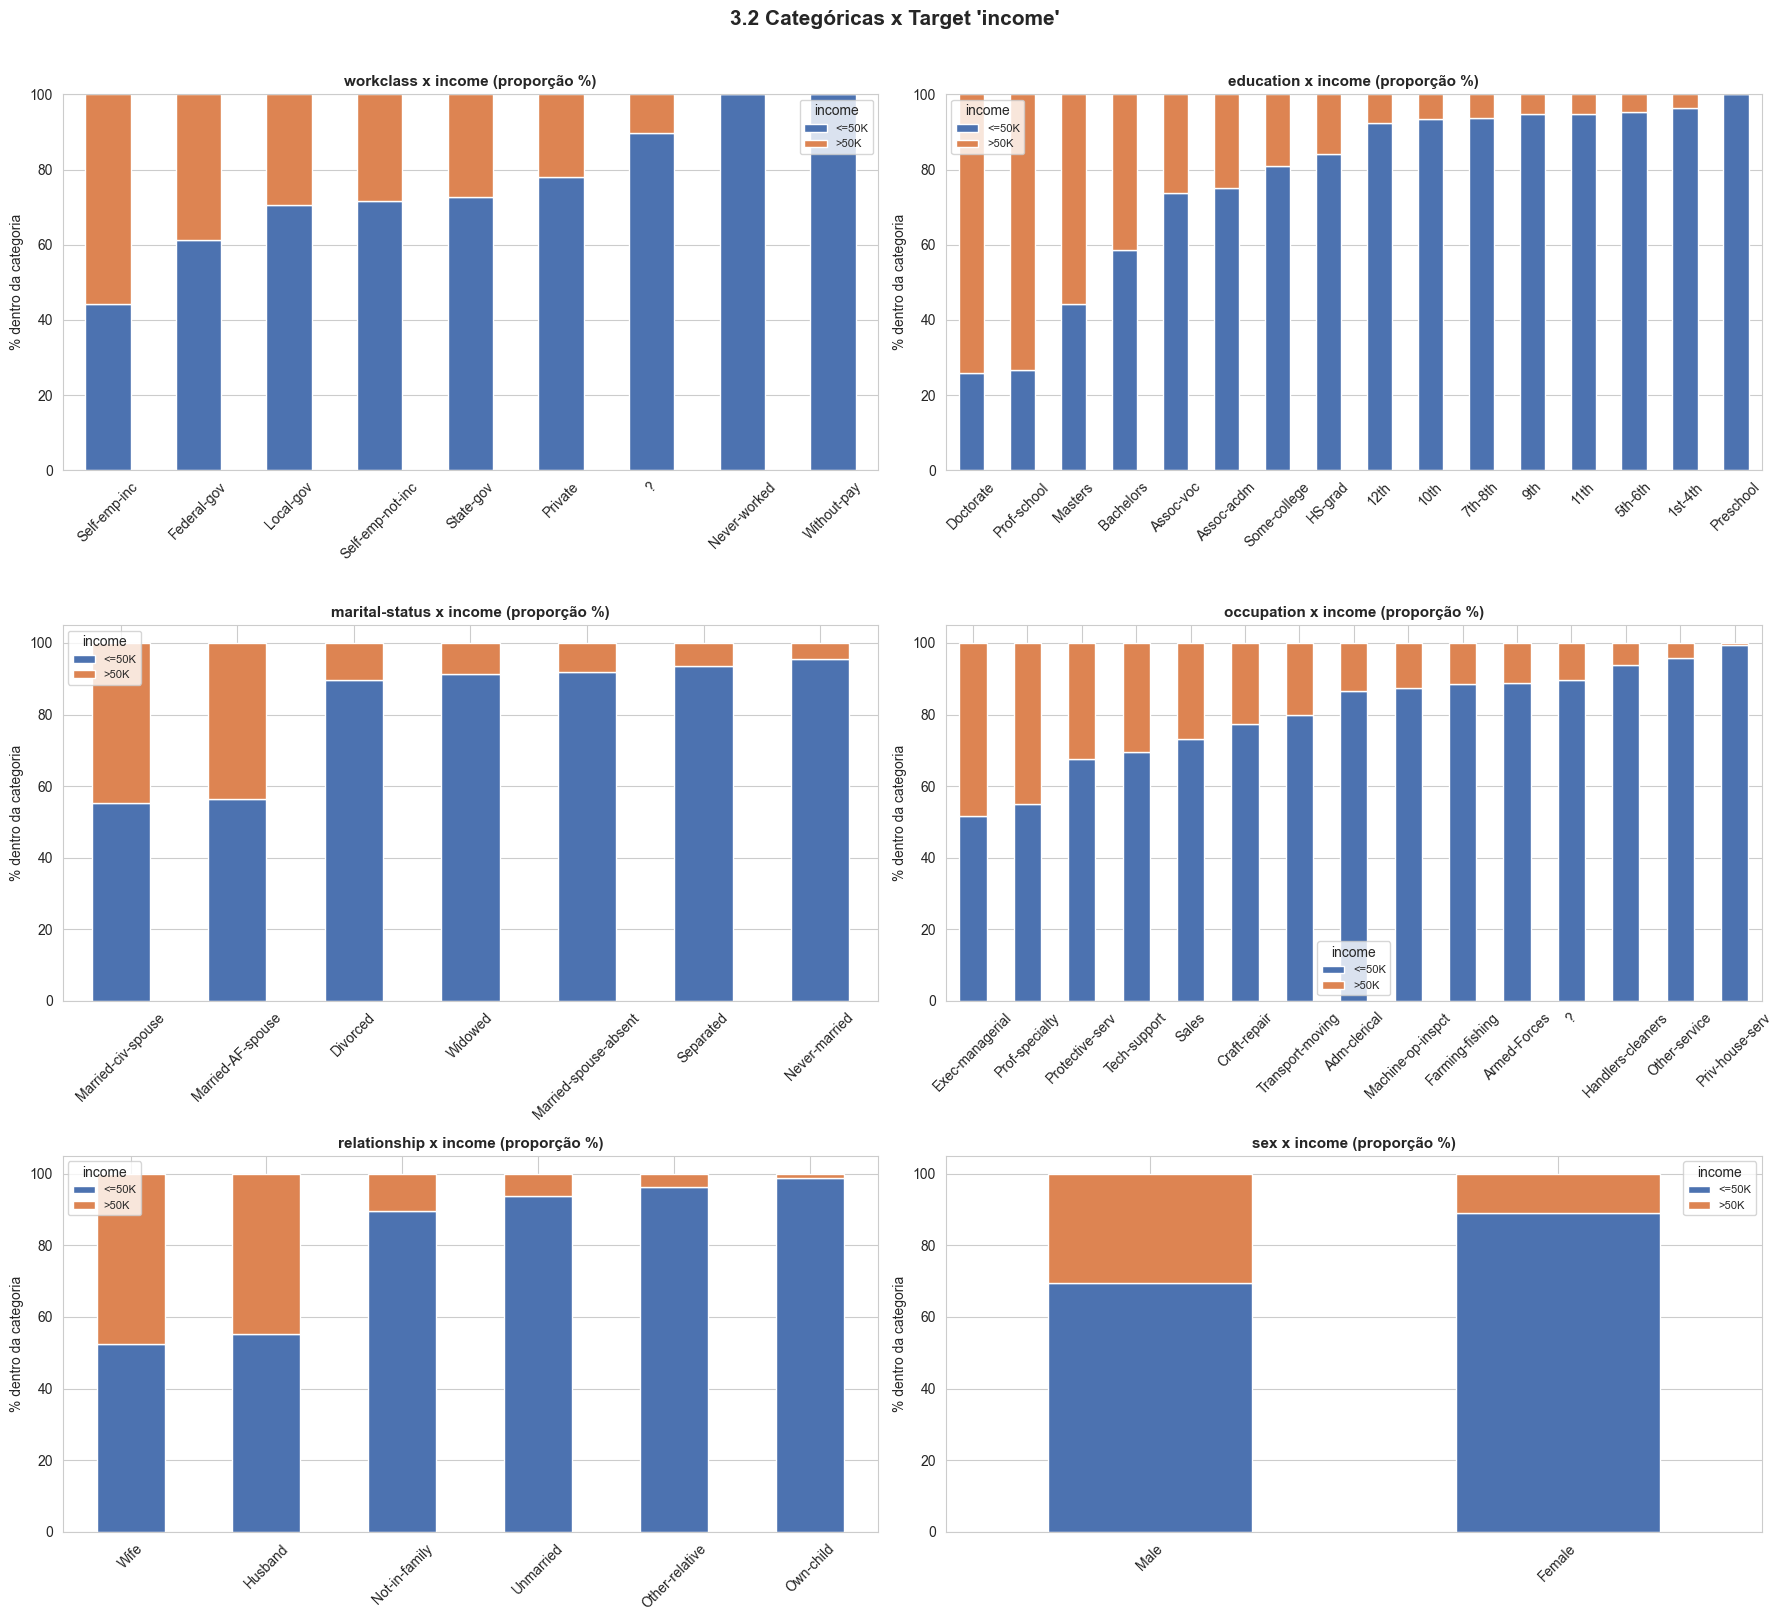

In [10]:
cat_for_target = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'sex']
cat_for_target = [c for c in cat_for_target if c in df.columns]

# Taxa de >50K por categoria
for col in cat_for_target:
    rate = (df.groupby(col)['income'].apply(lambda x: (x == '>50K').mean()) * 100).sort_values(ascending=False)
    print(f"{col} - Taxa de >50K (top 8 categorias)")
    print(rate.head(8).round(2).to_string())
    print()

# Barras empilhadas (proporção por income)
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_for_target):
    ax = axes[i]
    tab = pd.crosstab(df[col], df['income'], normalize='index') * 100
    tab = tab.sort_values(by='>50K', ascending=False)
    tab[['<=50K', '>50K']].plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{col} x income (proporção %)', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% dentro da categoria')
    ax.legend(title='income', fontsize=8)
    ax.tick_params(axis='x', labelrotation=45)

for j in range(len(cat_for_target), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("3.2 Categóricas x Target 'income'", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.3 Analisar relações entre variáveis numéricas e categóricas

- Comparar distribuições numéricas por classes do target com boxplots.
- Complementar com violin plot para visualizar dispersão por categoria.

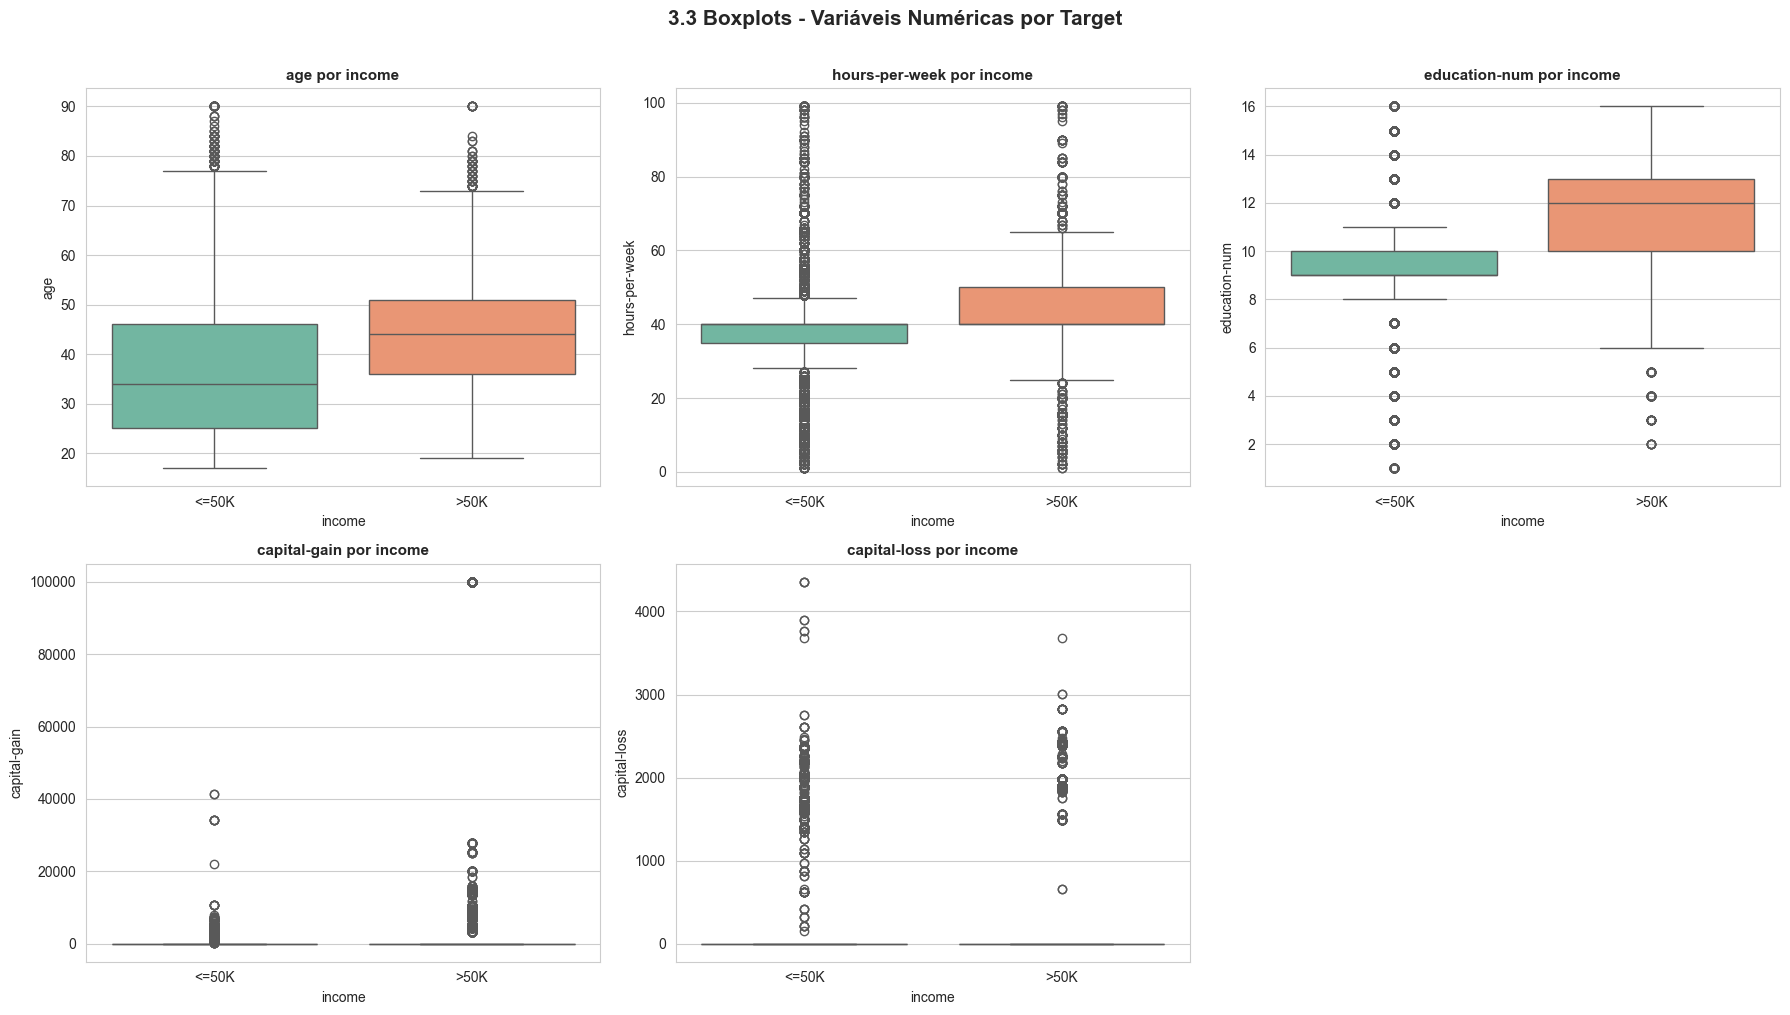

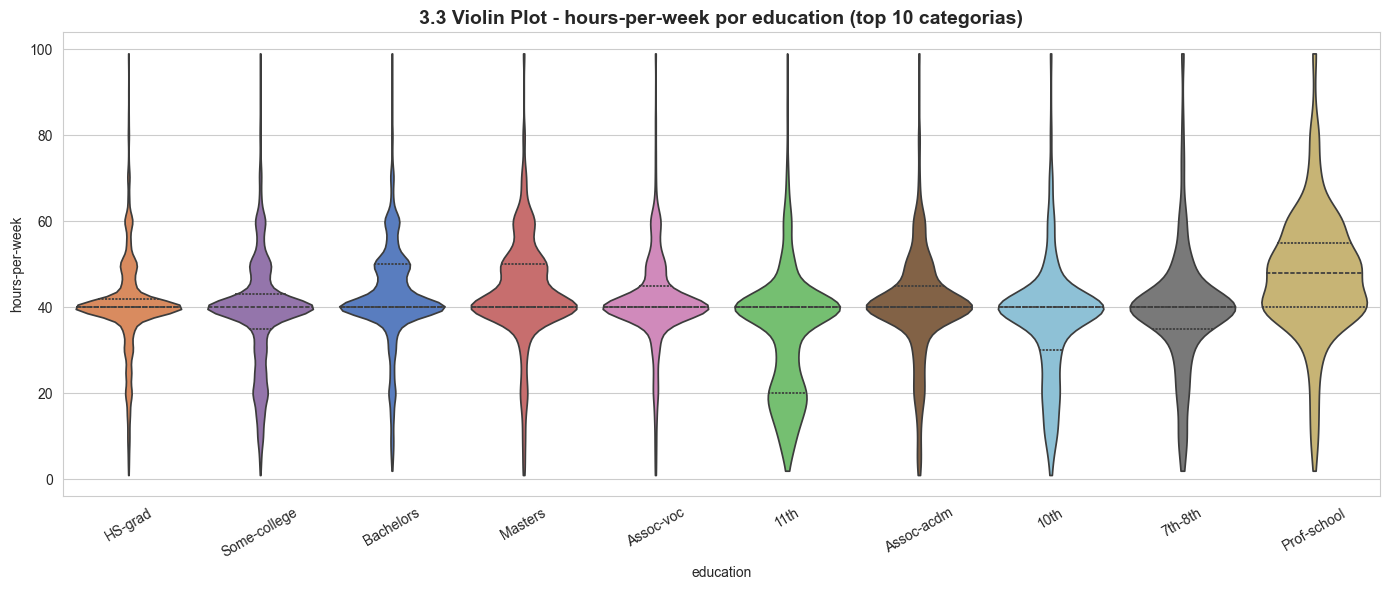

In [ ]:
# Boxplots para variáveis numéricas por income
num_for_box = [c for c in ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss'] if c in numerical]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_for_box):
    ax = axes[i]
    sns.boxplot(data=df, x='income', y=col, ax=ax, palette='Set2', hue='income', legend=False)
    ax.set_title(f'{col} por income', fontsize=11, fontweight='bold')
    ax.set_xlabel('income')
    ax.set_ylabel(col)

for j in range(len(num_for_box), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('3.3 Boxplots - Variáveis Numéricas por Target', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Exemplo numérica x categórica (education x hours-per-week)
plot_df = df[['education', 'hours-per-week']].copy()
order_edu = plot_df['education'].value_counts().head(10).index
plot_df = plot_df[plot_df['education'].isin(order_edu)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=plot_df, x='education', y='hours-per-week', order=order_edu, inner='quartile', cut=0, palette='muted', hue='education', legend=False)
plt.title('3.3 Violin Plot - hours-per-week por education (top 10 categorias)', fontsize=14, fontweight='bold')
plt.xlabel('education')
plt.ylabel('hours-per-week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()